In [1]:
import sys
from pathlib import Path
import os
import pandas as pd
sys.path.append(str(Path.cwd().parent))
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

In [ ]:
from src.load_data import get_moex_candles, save_candles_df
from datetime import datetime
start_date = datetime(2013, 1, 1)
end_date = datetime(2026, 3, 15)
ticker = "IMOEX"

candles = get_moex_candles(ticker, start_date, end_date, rest_time=0.5, interval=10, market="index")
save_candles_df(candles, "IMOEX.csv")

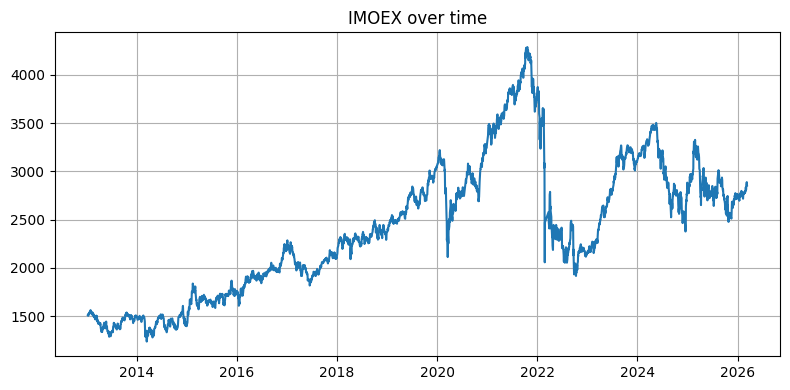

In [2]:
candles = pd.read_csv(os.path.join(DATA_DIR, "IMOEX.csv"))
candles['end'] = pd.to_datetime(candles['end'])
candles.set_index('end', inplace=True)
candles = candles.resample("D").agg({
    'open': 'first',
    'high': 'max',
    'low': 'min',
    'close': 'last',
    'volume': 'sum'  
}).dropna()

from matplotlib import pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(candles.index, candles['close'])
plt.title("IMOEX over time")
plt.grid()
plt.tight_layout()

In [3]:
from src.get_features import add_log_returns, add_volatility

candles = add_log_returns(candles, [1, 7, 14, 30, 90])
candles = add_volatility(candles, [7, 14, 30, 90])

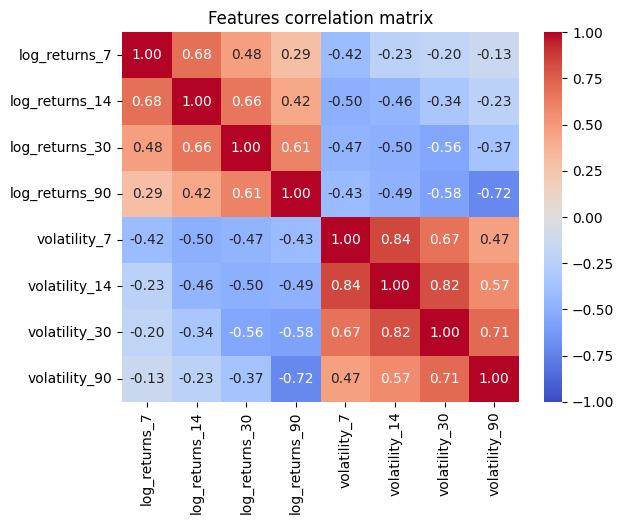

In [25]:
import seaborn as sns

features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90"
]
features_df = candles[features].dropna()
correlation_matrix_pd = features_df.corr()

sns.heatmap(correlation_matrix_pd, annot=True, cmap="vlag", fmt=".2f", center=0, vmin=-1, vmax=1)
plt.title("Features correlation matrix")
plt.show()

Model is not converging.  Current: 83455.4316988624 is not greater than 83455.485528197. Delta is -0.053829334588954225
Model is not converging.  Current: 83294.26766019416 is not greater than 83294.6319967963. Delta is -0.3643366021424299
Model is not converging.  Current: 84447.57815647329 is not greater than 84447.58486526065. Delta is -0.006708787361276336
Model is not converging.  Current: 83586.56296336986 is not greater than 83710.89667564897. Delta is -124.33371227911266
Model is not converging.  Current: 85726.1942973406 is not greater than 85726.19789373933. Delta is -0.0035963987320428714
Model is not converging.  Current: 84373.58418562064 is not greater than 84394.55536335826. Delta is -20.971177737621474
Model is not converging.  Current: 85522.90692678854 is not greater than 85682.02234237114. Delta is -159.11541558260797
Model is not converging.  Current: 84958.59148598579 is not greater than 84962.77052462182. Delta is -4.1790386360371485
Model is not converging.  Curr

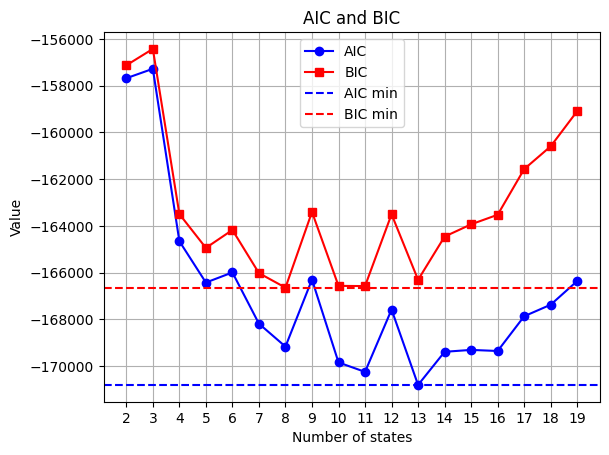

In [4]:
from src.train_hmm import train_hmm
features = [
    "log_returns_7", "log_returns_14", "log_returns_30", "log_returns_90",
    "volatility_7", "volatility_14", "volatility_30", "volatility_90"
]

candles = candles.dropna()
X = candles[features].values

bics = []
aics = []
ks = range(2, 20)
for k in ks:
    model = train_hmm(X, n_states=k, n_iter=5000)
    bics.append(model.bic(X))
    aics.append(model.aic(X))

plt.plot(ks, aics, marker='o', label='AIC', color='blue')
plt.plot(ks, bics, marker='s', label='BIC', color='red')

min_aic = min(aics)
min_bic = min(bics)
plt.axhline(min_aic, linestyle='--', label='AIC min', color='blue')
plt.axhline(min_bic, linestyle='--', label='BIC min', color='red')

plt.xlabel('Number of states')
plt.ylabel('Value')
plt.title('AIC and BIC')
plt.grid()
plt.xticks(ks)
plt.legend()
plt.show()

In [45]:
model = train_hmm(X, n_states=8, n_iter=5000)

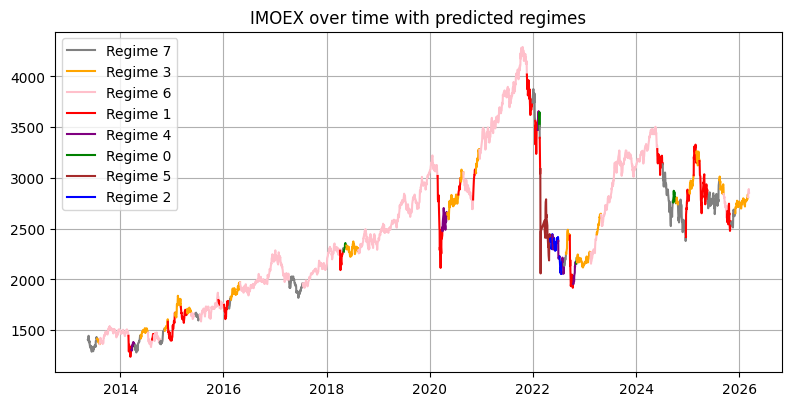

In [46]:
from src.visualization import plot_price_with_regimes
regimes = model.predict(X)
dates = candles.index
prices = candles['close'].values

plot_price_with_regimes(prices, dates, regimes)

In [47]:
candles['regime'] = regimes
statistics = candles.groupby('regime').agg({
    'log_returns_7': ['mean', 'std'],
    'volatility_7': ['mean', 'std'],
    'close':['count']
})

print(statistics)

       log_returns_7           volatility_7           close
                mean       std         mean       std count
regime                                                     
0           0.011566  0.029641     0.011399  0.005054    32
1          -0.012477  0.068255     0.020627  0.010816   353
2           0.000635  0.041870     0.016296  0.005654    42
3           0.009291  0.023292     0.009586  0.003596   542
4           0.010711  0.047497     0.018327  0.005584    86
5          -0.086621  0.172906     0.064469  0.064176    30
6           0.003463  0.023405     0.008098  0.003138  1746
7          -0.001257  0.036153     0.011957  0.004344   389


[[8.45062861e-001 3.81910296e-017 0.00000000e+000 9.31037834e-002
  2.20684665e-048 0.00000000e+000 3.35459179e-092 6.18333558e-002]
 [2.47776131e-106 9.46054329e-001 0.00000000e+000 1.73469864e-002
  1.11917341e-002 2.79729163e-003 5.79734334e-003 1.68123152e-002]
 [0.00000000e+000 0.00000000e+000 9.04234918e-001 0.00000000e+000
  9.57650816e-002 0.00000000e+000 0.00000000e+000 0.00000000e+000]
 [1.85302951e-068 1.09660293e-002 0.00000000e+000 9.65943754e-001
  1.89099223e-016 0.00000000e+000 2.12153399e-002 1.87487706e-003]
 [3.42574906e-002 1.73791713e-058 3.48444917e-002 1.16905073e-002
  9.07078860e-001 0.00000000e+000 0.00000000e+000 1.21286505e-002]
 [0.00000000e+000 0.00000000e+000 3.33333333e-002 0.00000000e+000
  0.00000000e+000 9.66666667e-001 0.00000000e+000 0.00000000e+000]
 [4.27867106e-108 5.94071739e-003 0.00000000e+000 4.84945173e-004
  0.00000000e+000 0.00000000e+000 9.91857333e-001 1.71700401e-003]
 [5.13802561e-003 7.76702106e-003 0.00000000e+000 1.87198076e-002
  3

Text(50.722222222222214, 0.5, 'from')

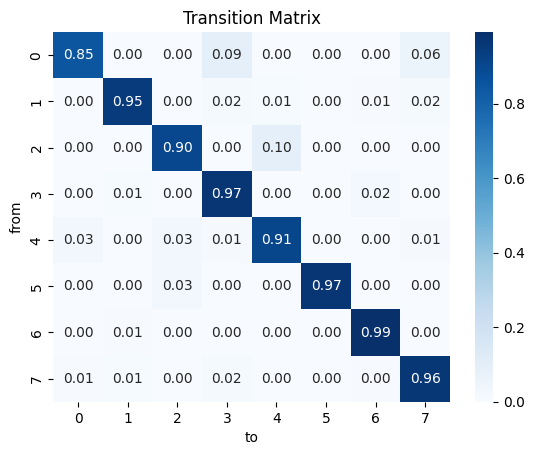

In [48]:
import seaborn as sns
sns.heatmap(model.transmat_, annot=True, cmap="Blues", fmt=".2f")
print(model.transmat_)
plt.title("Transition Matrix")
plt.xlabel("to")
plt.ylabel("from")

In [59]:
import numpy as np
trans = model.transmat_
expected_duration = 1 / (1 - np.diag(trans))
df = pd.DataFrame({
    "Stay Probability": np.diag(trans),
    "Expected regime duration (days)": np.round(expected_duration, 2)
})
print(df)

   Stay Probability  Expected regime duration (days)
0          0.845063                             6.45
1          0.946054                            18.54
2          0.904235                            10.44
3          0.965944                            29.36
4          0.907079                            10.76
5          0.966667                            30.00
6          0.991857                           122.81
7          0.963953                            27.74


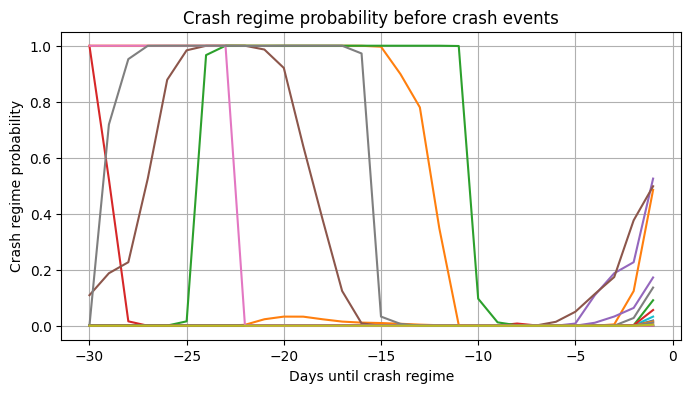

In [60]:
crash_regime = 1
probs = model.predict_proba(X)
crash_prob = probs[:, crash_regime]
candles["crash_prob"] = crash_prob

plt.figure(figsize=(8, 4))
crash_starts = []
for i in range(1, len(regimes)):
    if regimes[i] == 1 and regimes[i-1] != 1:
        crash_starts.append(i)

window = 30
for index in crash_starts:
    start = max(0, index-window)
    end = index
    
    plt.plot(range(-(end-start), 0), crash_prob[start:end])

plt.xlabel("Days until crash regime")
plt.ylabel("Crash regime probability")
plt.title("Crash regime probability before crash events")
plt.grid()

plt.show()